# FIIO 0004_U1_S3_TS  
**Asignatura:** Introducción a la Ciencia de Datos  

## Integrantes
- Jorge Cortes
- Richard Cortes

## Objetivo
Desarrollar un análisis exploratorio de datos (EDA) sobre un conjunto de datos de clientes de una tienda en línea, aplicando inspección inicial, limpieza, transformación, reducción de dimensionalidad con PCA y visualizaciones.



## 1. Importación de librerías y configuración inicial

En esta sección se importan las librerías necesarias para el desarrollo del taller. Se utilizarán `pandas` y `numpy` para el manejo de datos, `matplotlib` y `seaborn` para las visualizaciones, y herramientas de `scikit-learn` para la imputación, estandarización y el análisis PCA.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Construcción del dataset

Se agregan algunos valores nulos y atípicos para simular problemas reales de calidad de datos y poder aplicar técnicas de limpieza.


In [2]:
np.random.seed(42)

n_clientes = 1000
data = {
    'ID_Cliente': np.arange(1, n_clientes + 1),
    'Edad': np.random.randint(18, 80, n_clientes),
    'Ingresos_Anuales': np.random.normal(loc=50000, scale=15000, size=n_clientes),
    'Monto_Promedio_Compra': np.random.normal(loc=150, scale=50, size=n_clientes),
    'Frecuencia_Compra': np.random.randint(1, 15, n_clientes)
}

df = pd.DataFrame(data)

# Introducción de valores nulos y atípicos
df.loc[np.random.choice(df.index, 30), 'Ingresos_Anuales'] = np.nan
df.loc[np.random.choice(df.index, 20), 'Monto_Promedio_Compra'] = np.nan
df.loc[np.random.choice(df.index, 5), 'Edad'] = np.random.randint(100, 150, 5)
df.loc[np.random.choice(df.index, 10), 'Ingresos_Anuales'] = np.random.normal(loc=200000, scale=20000, size=10)

df.head()

,ID_Cliente,Edad,Ingresos_Anuales,Monto_Promedio_Compra,Frecuencia_Compra
0,1,56,70585.666948,145.618087,9
1,2,69,39833.208605,157.635895,4
2,3,46,67302.978080,179.409997,3
3,4,32,44374.840574,175.433412,1
4,5,60,39587.810697,28.414321,10


## 3. Inspección inicial del dataset

En esta parte se revisa la estructura general del dataframe, los tipos de datos, las estadísticas descriptivas y la cantidad de valores nulos por columna. Esto permite detectar los principales problemas antes de iniciar la limpieza.


In [3]:
print("Información general del dataset:")
df.info()

print("\nEstadísticas descriptivas:")
display(df.describe())

print("\nValores nulos por columna:")
display(df.isnull().sum())

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Cliente             1000 non-null   int64  
 1   Edad                   1000 non-null   int64  
 2   Ingresos_Anuales       970 non-null    float64
 3   Monto_Promedio_Compra  980 non-null    float64
 4   Frecuencia_Compra      1000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 39.2 KB

Estadísticas descriptivas:


,ID_Cliente,Edad,Ingresos_Anuales,Monto_Promedio_Compra,Frecuencia_Compra
count,1000.000000,1000.000000,970.000000,980.000000,1000.000000
mean,500.500000,50.215000,52080.621326,152.268672,7.722000
std,288.819436,18.809428,21255.354054,50.873708,4.065125
min,1.000000,18.000000,-3523.079490,4.923816,1.000000
25%,250.750000,35.000000,40631.939513,117.081042,4.000000
50%,500.500000,50.000000,51277.665817,153.396869,8.000000
75%,750.250000,66.000000,61737.439483,186.845580,11.000000
max,1000.000000,137.000000,220767.553095,312.732365,14.000000



Valores nulos por columna:


ID_Cliente                0
Edad                      0
Ingresos_Anuales         30
Monto_Promedio_Compra    20
Frecuencia_Compra         0
dtype: int64

## 4. Visualización antes de la limpieza

Se generan histogramas y boxplots para observar la distribución de las variables numéricas y detectar de forma visual la presencia de valores atípicos y posibles anomalías en los datos.


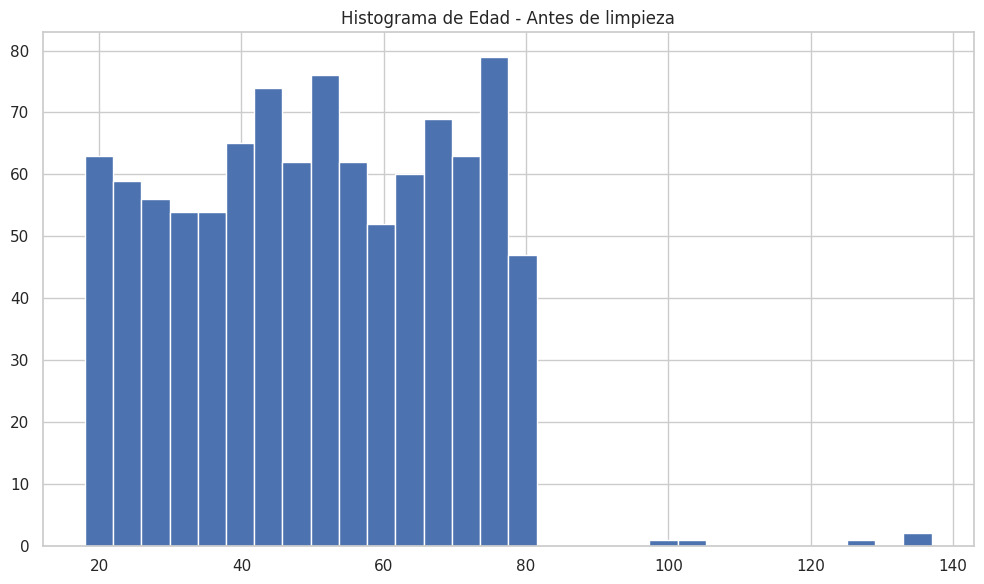

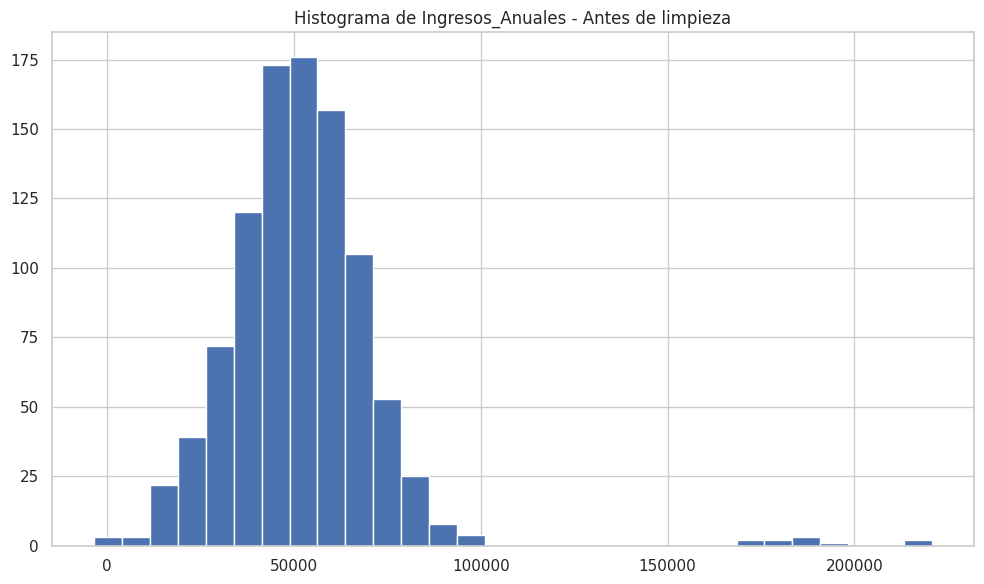

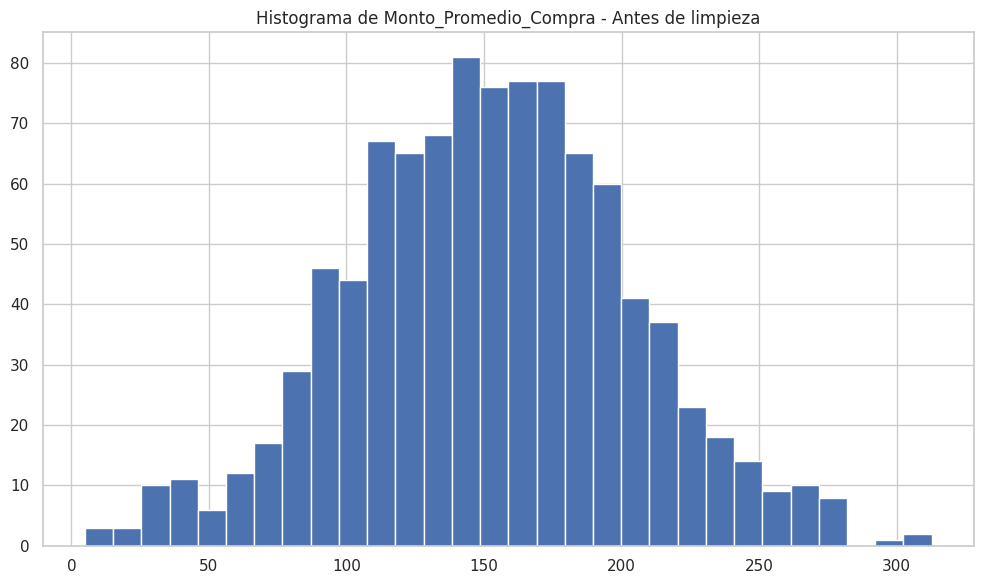

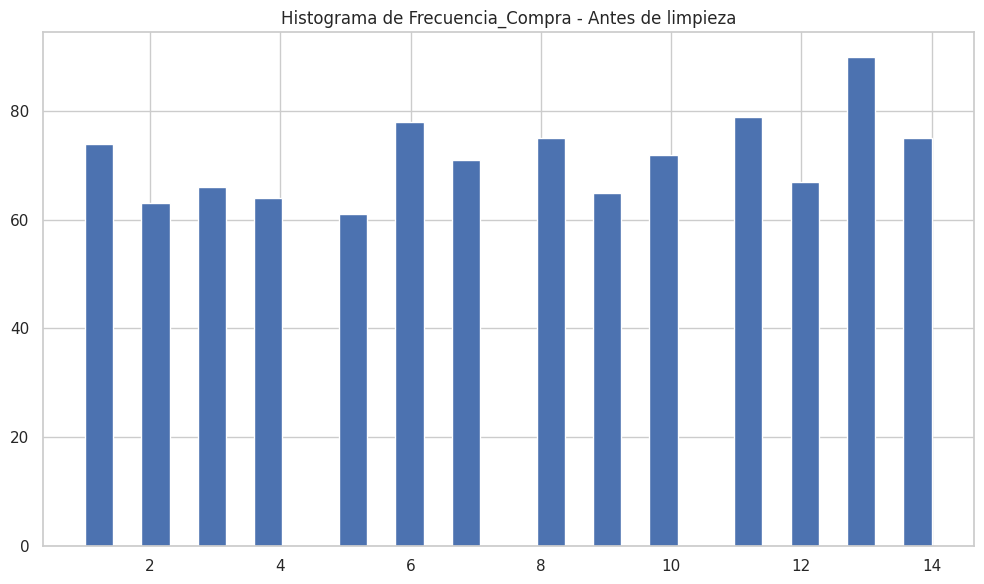

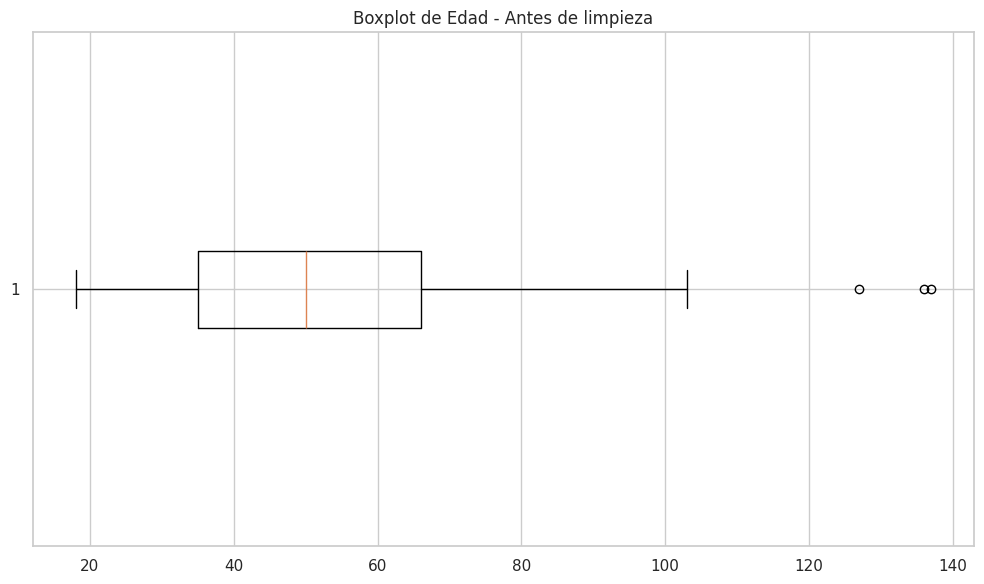

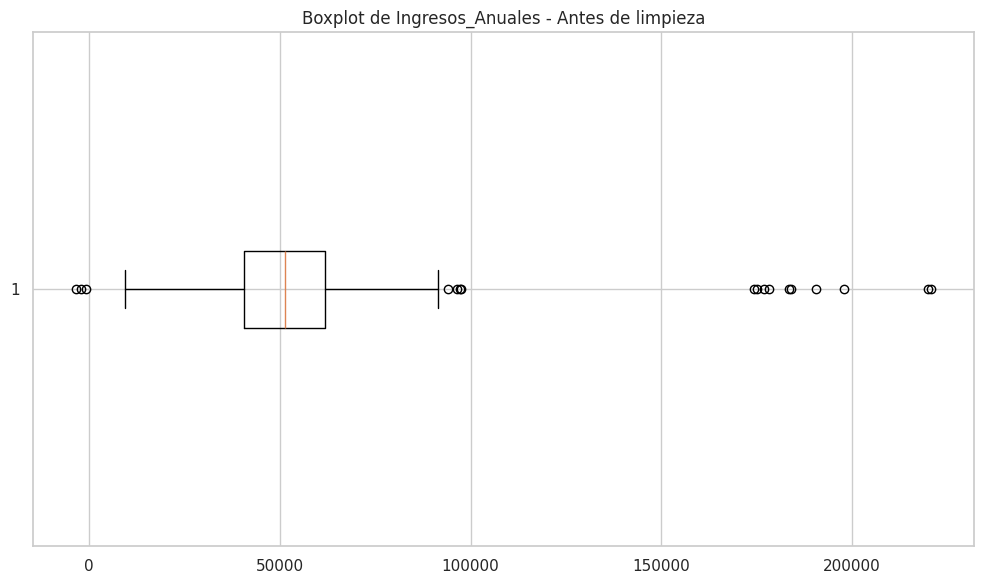

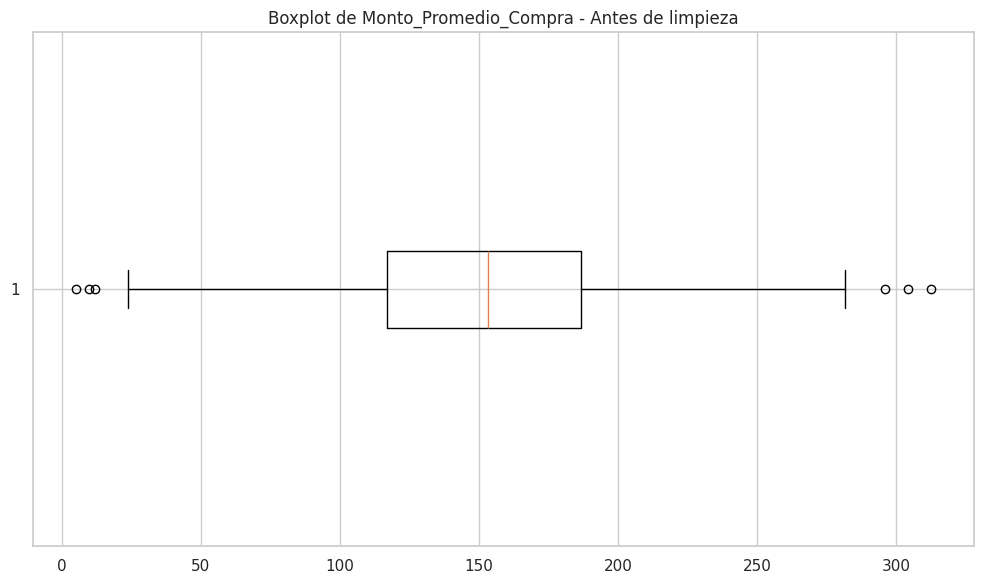

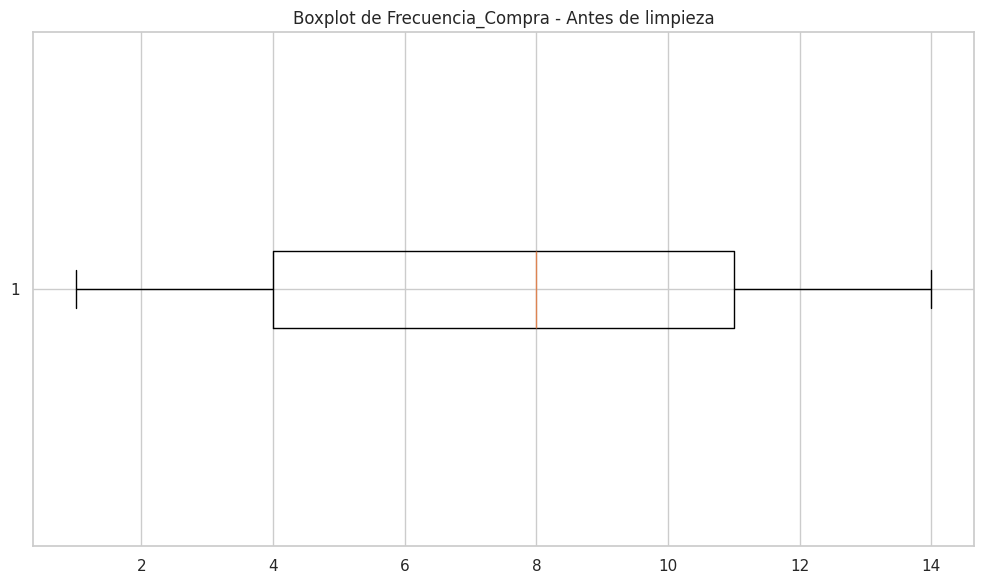

In [4]:
columnas_numericas = ['Edad', 'Ingresos_Anuales', 'Monto_Promedio_Compra', 'Frecuencia_Compra']

for col in columnas_numericas:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Histograma de {col} - Antes de limpieza')
    plt.tight_layout()
    plt.show()

for col in columnas_numericas:
    plt.figure()
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot de {col} - Antes de limpieza')
    plt.tight_layout()
    plt.show()

## 5. Limpieza de datos

En esta etapa se corrigen los problemas encontrados en la inspección inicial.  
- Los valores nulos de `Ingresos_Anuales` y `Monto_Promedio_Compra` se imputan utilizando la mediana.
- Las edades irreales mayores a 99 años se reemplazan por la mediana de las edades válidas.

Esta decisión se toma porque la mediana es menos sensible a valores extremos que el promedio.


In [5]:
df_limpio = df.copy()

imputer = SimpleImputer(strategy='median')
df_limpio[['Ingresos_Anuales', 'Monto_Promedio_Compra']] = imputer.fit_transform(
    df_limpio[['Ingresos_Anuales', 'Monto_Promedio_Compra']]
)

mediana_edad_valida = df_limpio.loc[df_limpio['Edad'] <= 99, 'Edad'].median()
df_limpio.loc[df_limpio['Edad'] > 99, 'Edad'] = mediana_edad_valida

print("Valores nulos luego de la imputación:")
display(df_limpio.isnull().sum())

print("Cantidad de edades irreales luego de la corrección:")
print((df_limpio['Edad'] > 99).sum())

print("\nEstadísticas descriptivas luego de la limpieza:")
display(df_limpio.describe())

Valores nulos luego de la imputación:


ID_Cliente               0
Edad                     0
Ingresos_Anuales         0
Monto_Promedio_Compra    0
Frecuencia_Compra        0
dtype: int64

Cantidad de edades irreales luego de la corrección:
0

Estadísticas descriptivas luego de la limpieza:


,ID_Cliente,Edad,Ingresos_Anuales,Monto_Promedio_Compra,Frecuencia_Compra
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,49.861000,52056.532661,152.291236,7.722000
std,288.819436,18.096717,20934.220479,50.362135,4.065125
min,1.000000,18.000000,-3523.079490,4.923816,1.000000
25%,250.750000,35.000000,40953.657897,118.923236,4.000000
50%,500.500000,50.000000,51277.665817,153.396869,8.000000
75%,750.250000,66.000000,61378.573379,185.550733,11.000000
max,1000.000000,79.000000,220767.553095,312.732365,14.000000


### Discusión de la Parte 1

A partir de la inspección inicial se detectó que el dataset presentaba dos problemas principales: valores nulos y datos atípicos. Los valores faltantes estaban presentes en las variables `Ingresos_Anuales` y `Monto_Promedio_Compra`, mientras que en la variable `Edad` aparecían registros irreales por sobre 99 años.

Para resolver estos problemas se utilizó imputación por mediana, ya que esta medida es robusta frente a valores extremos. En el caso de las edades irreales, se optó por reemplazarlas por la mediana de las edades válidas, manteniendo la coherencia del conjunto de datos. Después de esta limpieza, el dataset quedó en mejores condiciones para continuar con el análisis exploratorio.


## 6. Visualización después de la limpieza

Se repiten los histogramas y boxplots para comparar el comportamiento de las variables antes y después de la limpieza. De esta forma, se puede evaluar si las correcciones realizadas mejoraron la consistencia del conjunto de datos.


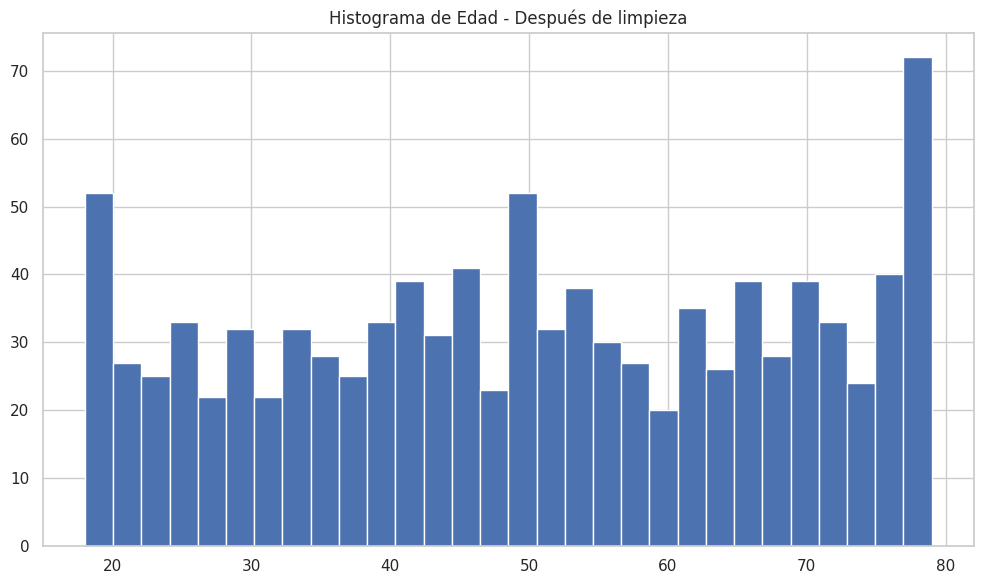

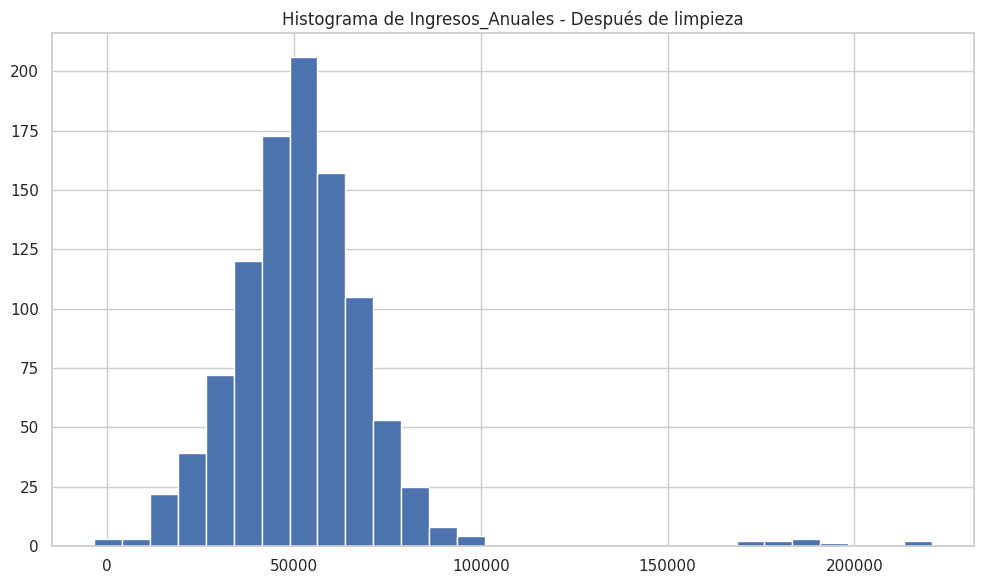

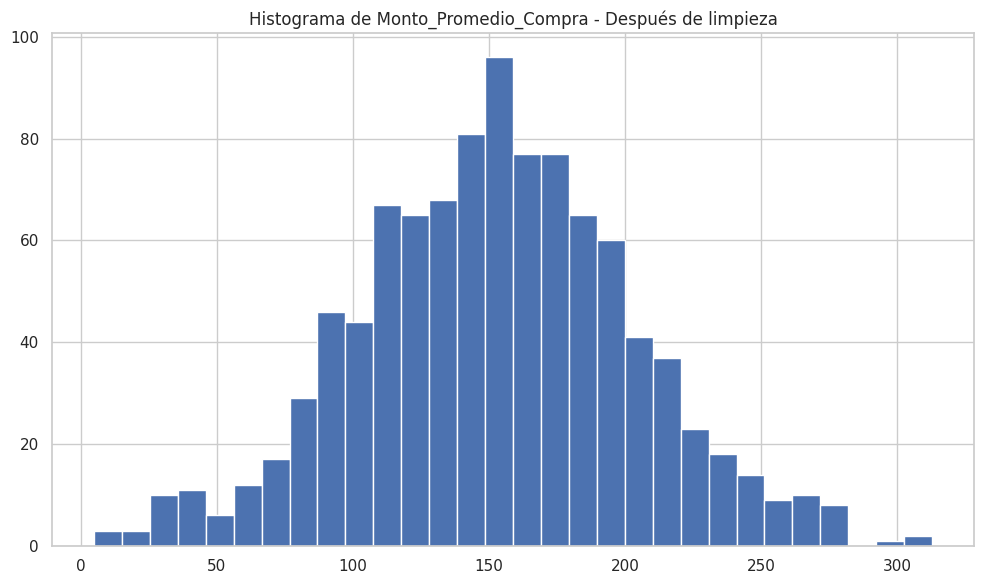

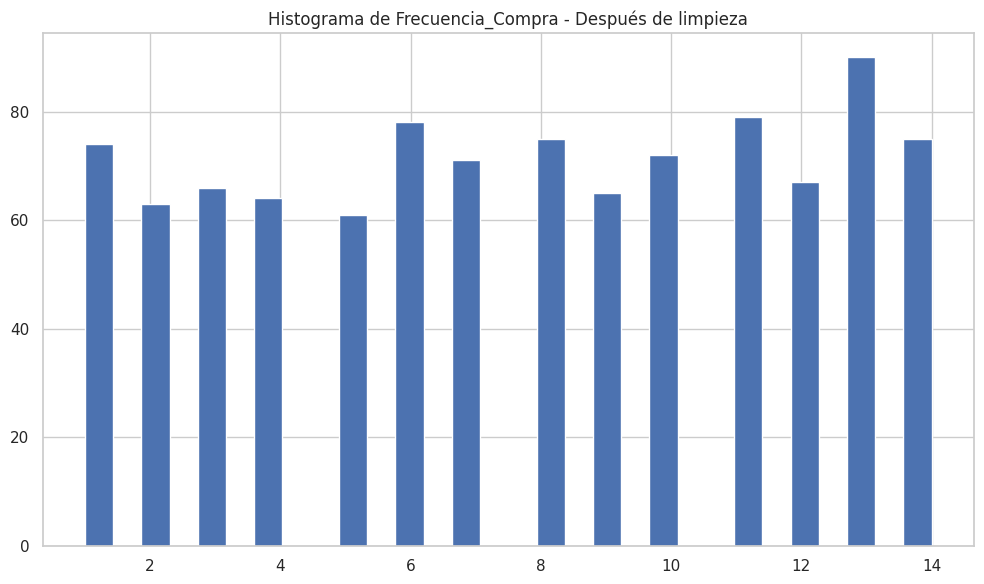

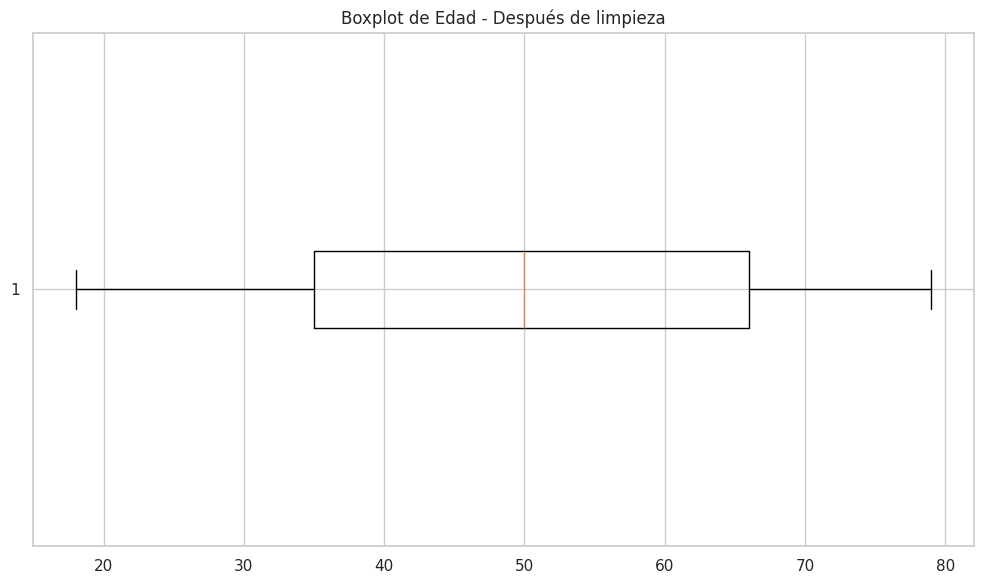

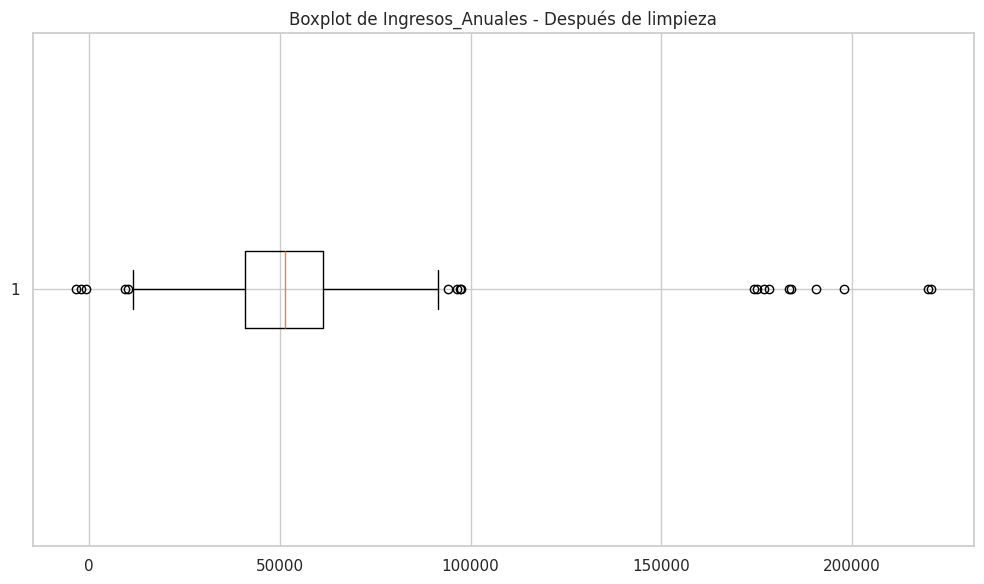

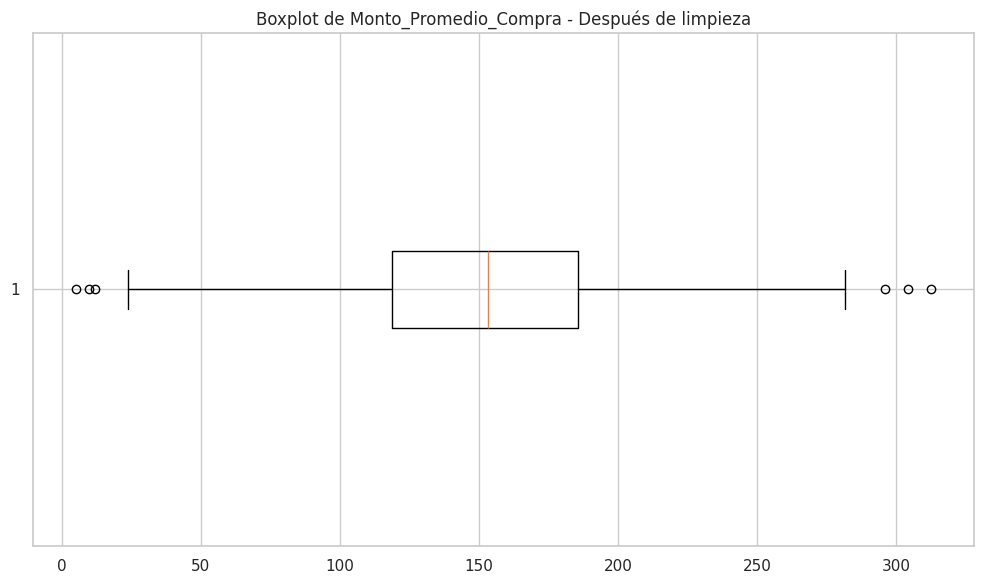

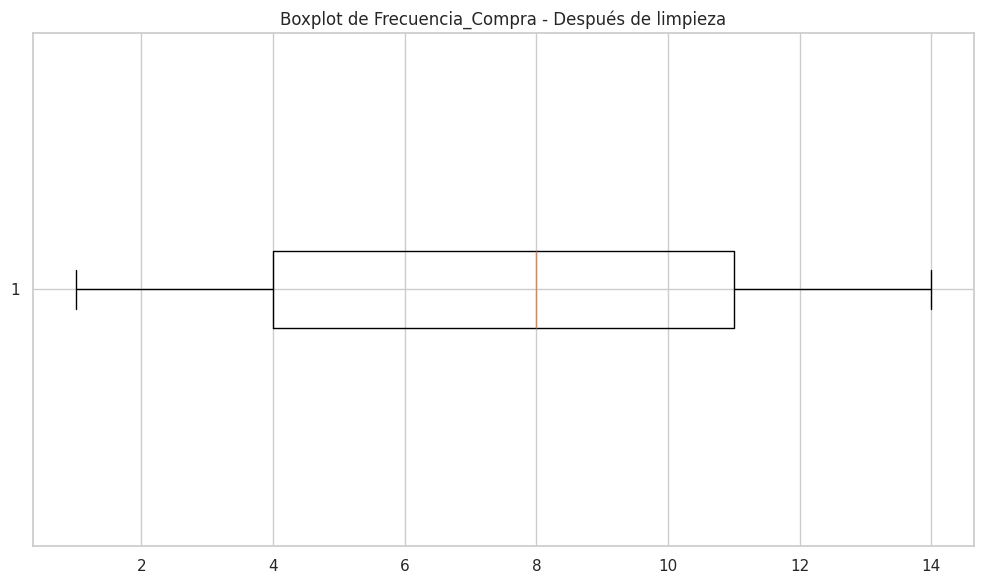

In [6]:
for col in columnas_numericas:
    plt.figure()
    plt.hist(df_limpio[col].dropna(), bins=30)
    plt.title(f'Histograma de {col} - Después de limpieza')
    plt.tight_layout()
    plt.show()

for col in columnas_numericas:
    plt.figure()
    plt.boxplot(df_limpio[col].dropna(), vert=False)
    plt.title(f'Boxplot de {col} - Después de limpieza')
    plt.tight_layout()
    plt.show()

## 7. Transformación de datos: estandarización

Se aplica `StandardScaler` sobre las variables numéricas para llevarlas a una misma escala. Esto es importante porque variables como los ingresos anuales tienen un rango muy distinto al de la edad o la frecuencia de compra. La estandarización facilita comparaciones y mejora el comportamiento de técnicas como PCA.


In [7]:
scaler = StandardScaler()
variables_escaladas = ['Edad', 'Ingresos_Anuales', 'Monto_Promedio_Compra', 'Frecuencia_Compra']

df_escalado = df_limpio.copy()
df_escalado[[col + '_std' for col in variables_escaladas]] = scaler.fit_transform(df_limpio[variables_escaladas])

display(df_escalado[['Edad_std', 'Ingresos_Anuales_std', 'Monto_Promedio_Compra_std', 'Frecuencia_Compra_std']].head())

,Edad_std,Ingresos_Anuales_std,Monto_Promedio_Compra_std,Frecuencia_Compra_std
0,0.339403,0.885555,-0.132570,0.314539
1,1.058124,-0.584184,0.106178,-0.916051
2,-0.213460,0.728667,0.538745,-1.162169
3,-0.987468,-0.367128,0.459745,-1.654405
4,0.560548,-0.595912,-2.460954,0.560657


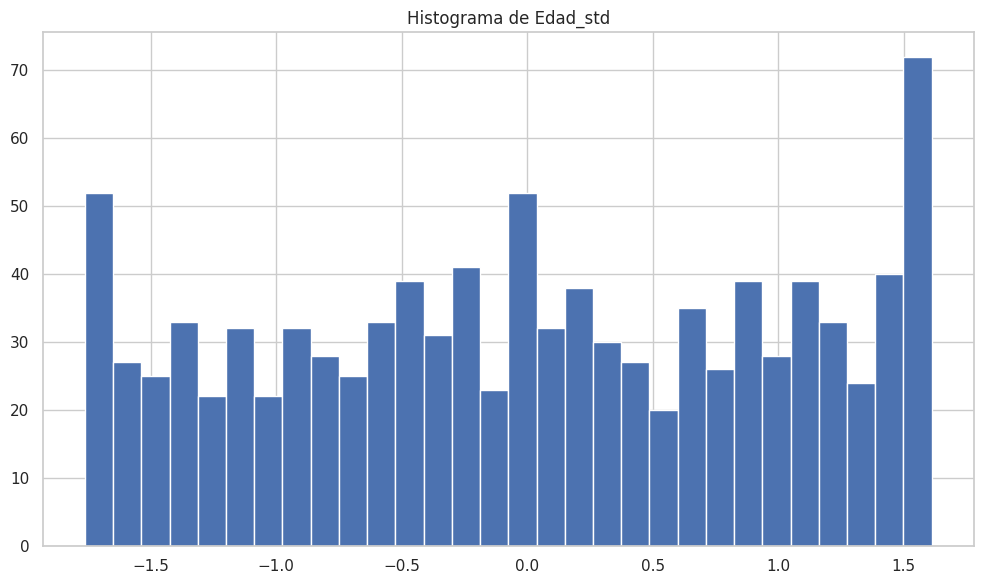

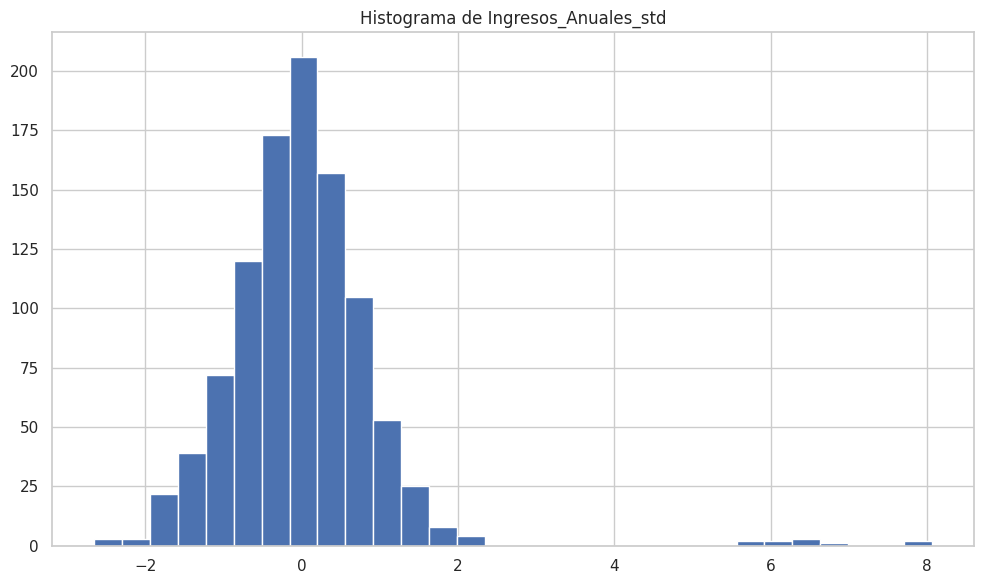

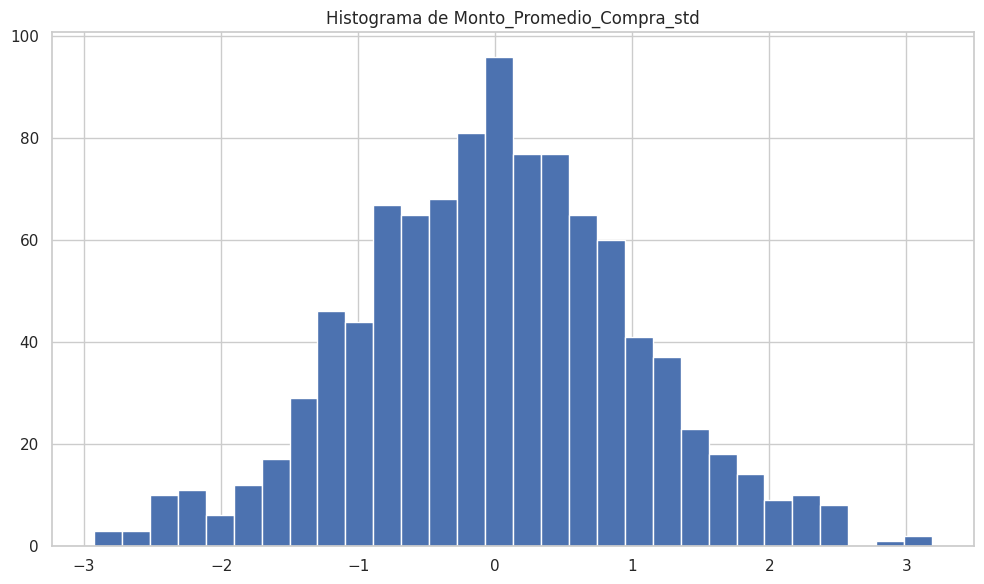

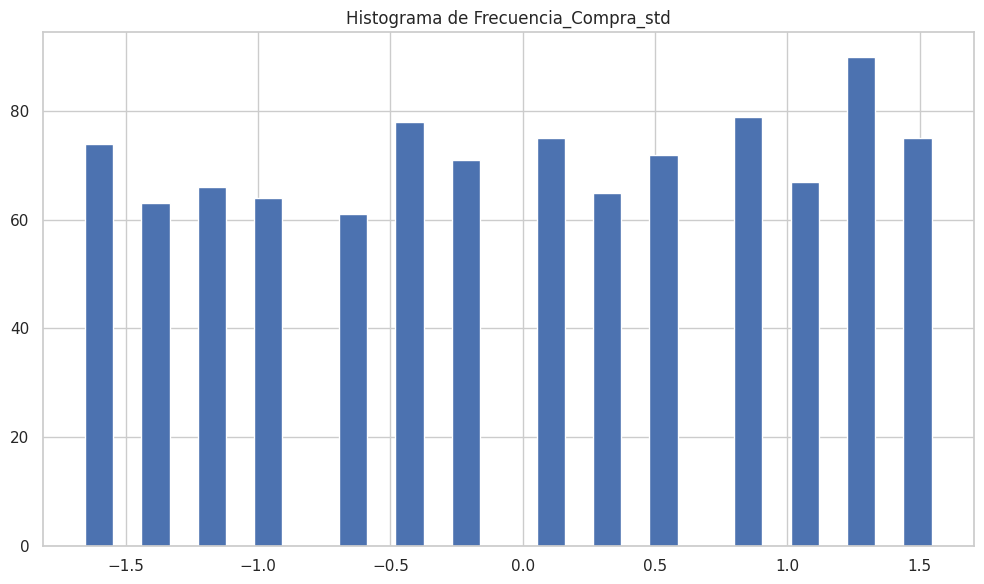

In [8]:
for col in [c + '_std' for c in variables_escaladas]:
    plt.figure()
    plt.hist(df_escalado[col].dropna(), bins=30)
    plt.title(f'Histograma de {col}')
    plt.tight_layout()
    plt.show()

## 8. Análisis de Componentes Principales (PCA)

Se aplica PCA utilizando las variables `Edad` e `Ingresos_Anuales`, tal como solicita el taller. Antes del PCA, ambas variables son estandarizadas para asegurar que ninguna domine el análisis solo por su magnitud.

Luego se calculan dos componentes principales (`PC1` y `PC2`) y se revisa la proporción de varianza explicada.


In [9]:
X_pca = df_limpio[['Edad', 'Ingresos_Anuales']]

scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca)

pca = PCA(n_components=2)
componentes = pca.fit_transform(X_pca_scaled)

df_limpio['PC1'] = componentes[:, 0]
df_limpio['PC2'] = componentes[:, 1]

print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

display(df_limpio[['Edad', 'Ingresos_Anuales', 'PC1', 'PC2']].head())

Varianza explicada por cada componente:
[0.51502438 0.48497562]


,Edad,Ingresos_Anuales,PC1,PC2
0,56,70585.666948,-0.386188,0.866176
1,69,39833.208605,1.161287,0.335126
2,46,67302.978080,-0.666185,0.364306
3,32,44374.840574,-0.438647,-0.957844
4,60,39587.810697,0.817741,-0.025007


### Discusión de la Parte 2

La estandarización permitió que todas las variables quedaran en una escala comparable, lo que es fundamental cuando se trabaja con métodos que dependen de la magnitud de los datos. Esto evita que variables con valores más grandes, como `Ingresos_Anuales`, tengan una influencia desproporcionada sobre el análisis.

En cuanto al PCA, esta técnica permitió resumir la información de dos variables en dos componentes principales ortogonales. Aunque en este caso se mantienen dos componentes, el procedimiento sirve para entender cómo se distribuye la varianza de los datos y preparar futuras etapas de reducción de dimensionalidad o modelado.


## 9. Visualizaciones finales y exploración de relaciones

En esta sección se generan visualizaciones adicionales para explorar relaciones entre variables del dataset y apoyar la interpretación final del análisis.


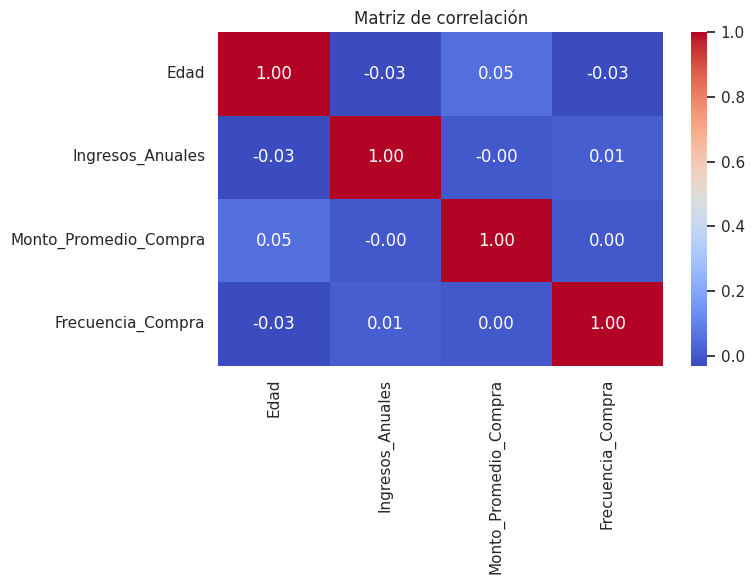

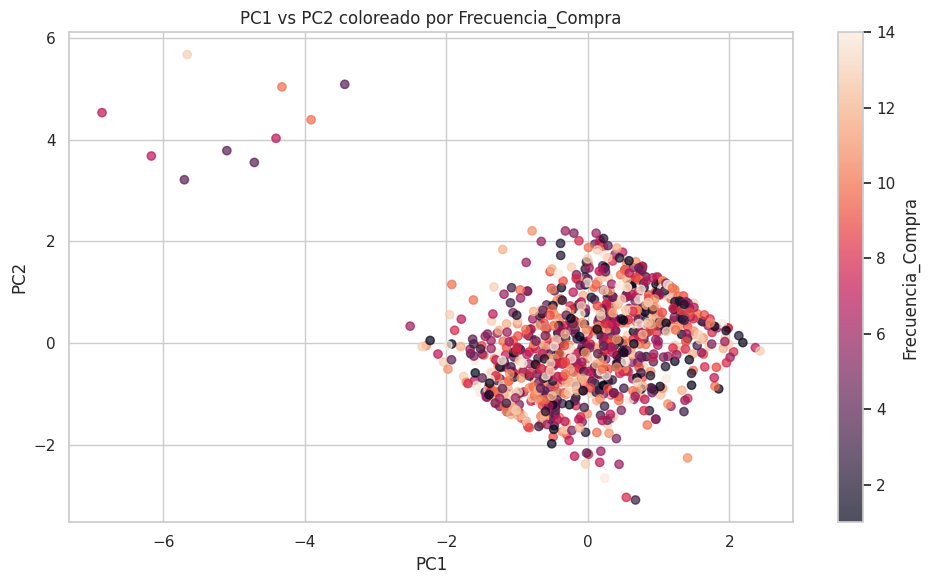

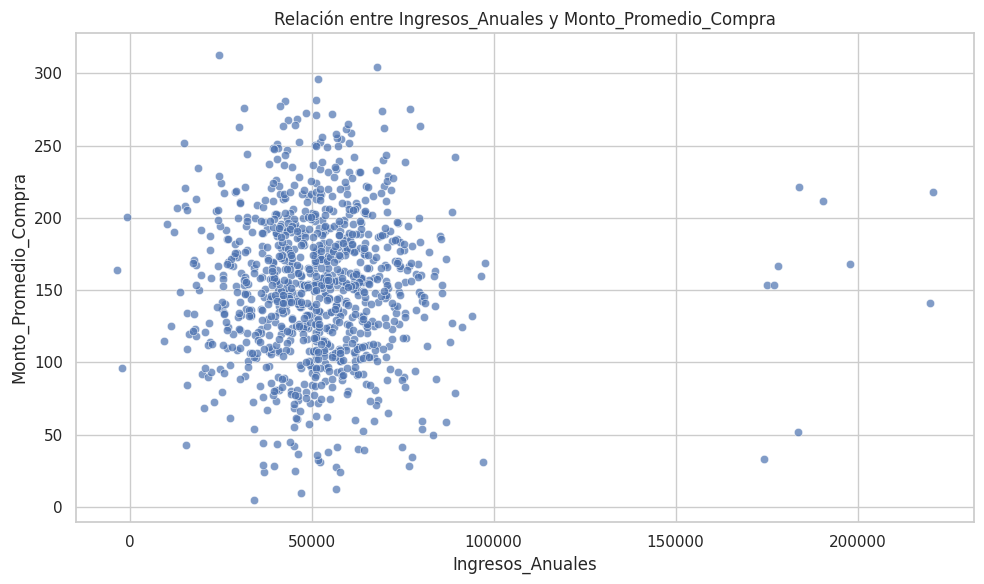

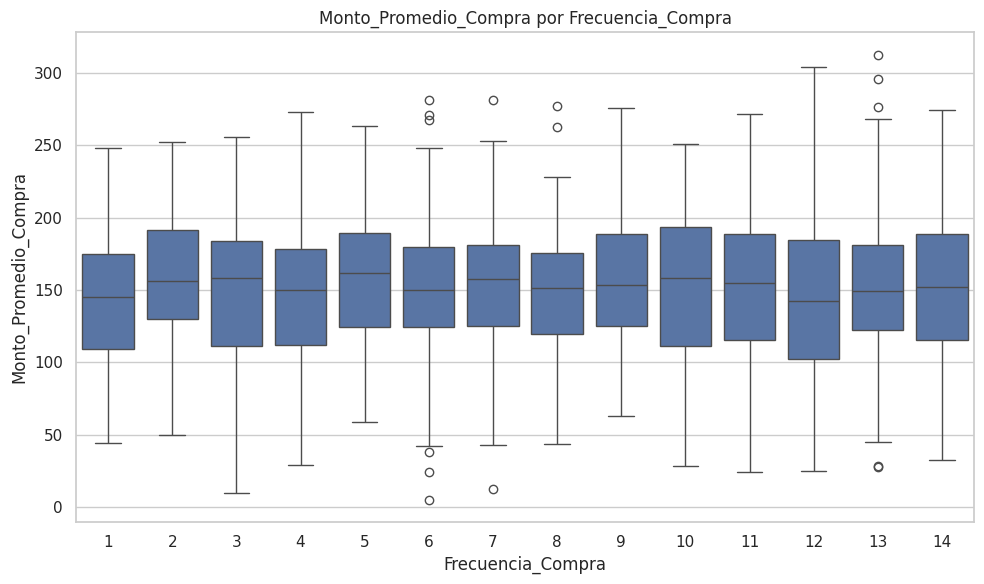

In [10]:
# Matriz de correlación
plt.figure(figsize=(8, 6))
corr = df_limpio[['Edad', 'Ingresos_Anuales', 'Monto_Promedio_Compra', 'Frecuencia_Compra']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

# PC1 vs PC2 coloreado por frecuencia de compra
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_limpio['PC1'],
    df_limpio['PC2'],
    c=df_limpio['Frecuencia_Compra'],
    alpha=0.7
)
plt.colorbar(scatter, label='Frecuencia_Compra')
plt.title('PC1 vs PC2 coloreado por Frecuencia_Compra')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

# Relación entre ingresos y monto promedio de compra
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_limpio, x='Ingresos_Anuales', y='Monto_Promedio_Compra', alpha=0.7)
plt.title('Relación entre Ingresos_Anuales y Monto_Promedio_Compra')
plt.tight_layout()
plt.show()

# Boxplot de monto promedio según frecuencia de compra
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_limpio, x='Frecuencia_Compra', y='Monto_Promedio_Compra')
plt.title('Monto_Promedio_Compra por Frecuencia_Compra')
plt.tight_layout()
plt.show()

## 10. Conclusiones

En la inspección inicial se detectaron valores nulos en las variables `Ingresos_Anuales` y `Monto_Promedio_Compra`, además de edades irreales superiores a 99 años. Esto confirmó que el dataset requería una fase previa de limpieza antes de realizar cualquier análisis exploratorio más profundo.

La imputación por mediana permitió conservar los registros sin alterar excesivamente la distribución de los datos, mientras que la corrección de edades irregulares mejoró la consistencia general del conjunto. Después de la limpieza, fue posible continuar con mayor seguridad hacia las etapas de transformación y análisis.

La estandarización dejó las variables en una escala comparable, lo que facilitó la aplicación de técnicas sensibles a diferencias de magnitud. Posteriormente, el PCA aplicado sobre `Edad` e `Ingresos_Anuales` permitió resumir la información en dos componentes principales y observar su varianza explicada.

Finalmente, las visualizaciones mostraron que no existe una correlación extremadamente fuerte entre todas las variables, aunque sí se observan relaciones que pueden explorarse con mayor profundidad en estudios posteriores. En conjunto, el EDA permitió pasar de un dataset con problemas de calidad a un conjunto de datos preparado para etapas futuras de modelado o análisis más avanzado.
